# 02 Prepare Forecasting Data

Creates regular business-day close-price series for N-BEATS, PatchTST, Chronos, and Kronos. The models forecast close price, and the benchmark converts forecasts to future returns.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
print('Project root:', PROJECT_ROOT)

Project root: c:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project


In [2]:
from src.config import DATA_RAW_DIR, DATA_PROCESSED_DIR, FREQ
from src.data_utils import prepare_all_raw_files, load_prepared_panel

summary = prepare_all_raw_files(DATA_RAW_DIR, DATA_PROCESSED_DIR, freq=FREQ)
summary

Prepared AAPL: 1908 rows
Prepared ABBV: 1908 rows
Prepared ABT: 1908 rows
Prepared ACN: 1908 rows
Prepared ADBE: 1908 rows
Prepared AMD: 1908 rows
Prepared AMZN: 1908 rows
Prepared AVGO: 1908 rows
Prepared BAC: 1908 rows
Prepared BLK: 1908 rows
Prepared CAT: 1908 rows
Prepared COST: 1908 rows
Prepared CRM: 1908 rows
Prepared CSCO: 1908 rows
Prepared CVX: 1908 rows
Prepared DIS: 1908 rows
Prepared GE: 1908 rows
Prepared GOOGL: 1908 rows
Prepared GS: 1908 rows
Prepared HD: 1908 rows
Prepared IBM: 1908 rows
Prepared INTC: 1908 rows
Prepared JNJ: 1908 rows
Prepared JPM: 1908 rows
Prepared KO: 1908 rows
Prepared LIN: 1908 rows
Prepared LLY: 1908 rows
Prepared MA: 1908 rows
Prepared MCD: 1908 rows
Prepared META: 1908 rows
Prepared MRK: 1908 rows
Prepared MS: 1908 rows
Prepared MSFT: 1908 rows
Prepared NFLX: 1908 rows
Prepared NKE: 1908 rows
Prepared NVDA: 1908 rows
Prepared ORCL: 1908 rows
Prepared PEP: 1908 rows
Prepared PFE: 1908 rows
Prepared PG: 1908 rows
Prepared PM: 1908 rows
Prepared 

,Ticker,rows,start,end
0,AAPL,1908,2019-01-02,2026-04-24
1,ABBV,1908,2019-01-02,2026-04-24
2,ABT,1908,2019-01-02,2026-04-24
3,ACN,1908,2019-01-02,2026-04-24
4,ADBE,1908,2019-01-02,2026-04-24
5,AMD,1908,2019-01-02,2026-04-24
6,AMZN,1908,2019-01-02,2026-04-24
7,AVGO,1908,2019-01-02,2026-04-24
8,BAC,1908,2019-01-02,2026-04-24
9,BLK,1908,2019-01-02,2026-04-24


In [3]:
panel = load_prepared_panel(DATA_PROCESSED_DIR)
print(panel.shape)
print(panel[['Ticker', 'Date', 'close']].head())
print(panel.groupby('Ticker').size())

(95400, 11)
  Ticker       Date      close
0   AAPL 2019-01-02  39.480000
1   AAPL 2019-01-03  35.547501
2   AAPL 2019-01-04  37.064999
3   AAPL 2019-01-07  36.982498
4   AAPL 2019-01-08  37.687500
Ticker
AAPL     1908
ABBV     1908
ABT      1908
ACN      1908
ADBE     1908
AMD      1908
AMZN     1908
AVGO     1908
BAC      1908
BLK      1908
CAT      1908
COST     1908
CRM      1908
CSCO     1908
CVX      1908
DIS      1908
GE       1908
GOOGL    1908
GS       1908
HD       1908
IBM      1908
INTC     1908
JNJ      1908
JPM      1908
KO       1908
LIN      1908
LLY      1908
MA       1908
MCD      1908
META     1908
MRK      1908
MS       1908
MSFT     1908
NFLX     1908
NKE      1908
NVDA     1908
ORCL     1908
PEP      1908
PFE      1908
PG       1908
PM       1908
QCOM     1908
TMO      1908
TSLA     1908
TXN      1908
UNH      1908
V        1908
WFC      1908
WMT      1908
XOM      1908
dtype: int64


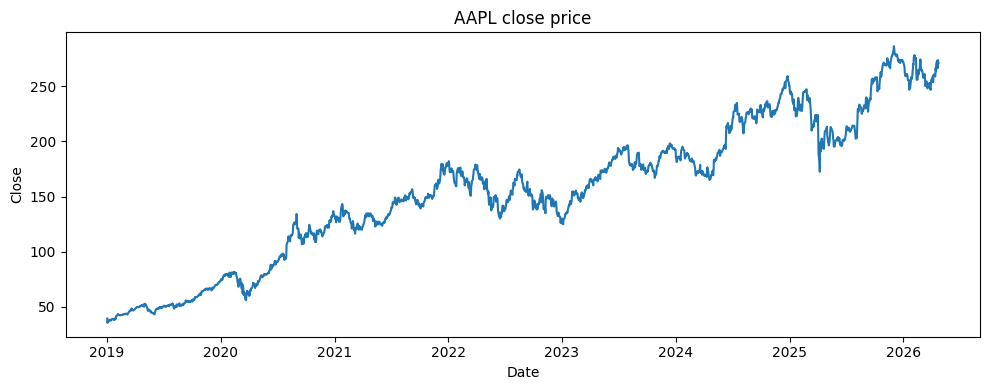

In [4]:
import matplotlib.pyplot as plt

ticker = panel['Ticker'].unique()[0]
g = panel[panel['Ticker'] == ticker]
plt.figure(figsize=(10, 4))
plt.plot(g['Date'], g['close'])
plt.title(f'{ticker} close price')
plt.xlabel('Date')
plt.ylabel('Close')
plt.tight_layout()